# BlindSpotter — MR-GCN (Multi-Relational GCN) 학습

**R-GCN 핵심 아이디어**: 엣지 타입마다 별도 가중치 행렬 $W_r$ 적용
$$h_i^{(l+1)} = \sigma\!\left(\sum_{r} \sum_{j \in \mathcal{N}_r(i)} \frac{1}{|\mathcal{N}_r(i)|} W_r^{(l)} h_j^{(l)} + W_0^{(l)} h_i^{(l)}\right)$$

| Relation | 의미 |
|---|---|
| `spatial_near` | 공간적으로 가까운 노드 간 일반 연결 |
| `occludes` | 차량이 PM을 가림 |
| `potential_conflict` | 충돌 위험 (거리 <5m) |
| `blind_zone_relation` | Blind Zone 노드 ↔ 주변 노드 |

In [3]:
# ── 0. 패키지 설치 (Colab용 — 로컬이면 스킵) ──────────────────
# !pip install -q torch torchvision
# !pip install -q torch_geometric
# !pip install -q pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
#   -f https://data.pyg.org/whl/torch-$(python -c "import torch;print(torch.__version__)").html

import torch
print('torch    :', torch.__version__)
print('cuda     :', torch.cuda.is_available())
try:
    import torch_geometric
    print('pyg      :', torch_geometric.__version__)
except ImportError:
    print('[ERROR] torch_geometric 미설치')

torch    : 2.12.0+cpu
cuda     : False


c:\Users\jien0\26S\CS471\BlindSpotter\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pyg      : 2.7.0


In [4]:
# ── 1. 임포트 & 설정 ────────────────────────────────────────────
import pickle, random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import RGCNConv

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, classification_report,
    precision_recall_curve, roc_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns

# ── 경로 ─────────────────────────────────────────────────────────
DATA_PKL = Path('../data/graph_dataset.pkl')
# Colab: DATA_PKL = Path('/content/drive/MyDrive/.../graph_dataset.pkl')

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED     = 42
BATCH    = 128
EPOCHS   = 50
LR       = 3e-4
HIDDEN   = 64
DROPOUT  = 0.3
DECOMPOS = 'basis'   # R-GCN basis decomposition: 'basis' | 'block' | None
N_BASES  = 4         # basis 수 (num_relations 이하)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'device: {DEVICE}  |  batch: {BATCH}  |  epochs: {EPOCHS}')
print(f'hidden: {HIDDEN}  |  decomp: {DECOMPOS}  |  n_bases: {N_BASES}')

device: cpu  |  batch: 128  |  epochs: 50
hidden: 64  |  decomp: basis  |  n_bases: 4


In [5]:
# ── 2. Relation 타입 매핑 ────────────────────────────────────────
# R-GCN은 edge_type을 정수 인덱스로 받음
RELATION_TYPES = ['spatial_near', 'occludes', 'potential_conflict', 'blind_zone_relation']
REL2ID = {r: i for i, r in enumerate(RELATION_TYPES)}
NUM_RELATIONS = len(RELATION_TYPES)

print('Relation → ID 매핑:')
for r, i in REL2ID.items():
    print(f'  {i}  {r}')
print(f'\nNUM_RELATIONS: {NUM_RELATIONS}')

Relation → ID 매핑:
  0  spatial_near
  1  occludes
  2  potential_conflict
  3  blind_zone_relation

NUM_RELATIONS: 4


In [6]:
# ── 3. PKL → PyG Dataset ────────────────────────────────────────
class BlindZoneRGCNDataset(Dataset):
    """graph_dataset.pkl 한 split을 R-GCN용 PyG Data로 변환."""

    def __init__(self, samples):
        super().__init__()
        self.samples = samples

    def len(self):
        return len(self.samples)

    def get(self, idx):
        s = self.samples[idx]

        x          = torch.tensor(s['x'],         dtype=torch.float)  # [N, node_dim]
        edge_index = torch.tensor(s['edge_index'], dtype=torch.long)  # [2, E]
        # edge_type: str 리스트 → 정수 텐서
        edge_type  = torch.tensor(
            [REL2ID.get(et, 0) for et in s['edge_type']],
            dtype=torch.long,
        )  # [E]
        y          = torch.tensor([s['label']],    dtype=torch.float)  # [1]
        bz_idx     = torch.tensor(s['bz_node_idx'],dtype=torch.long)   # scalar

        return Data(
            x=x, edge_index=edge_index, edge_type=edge_type,
            y=y, bz_idx=bz_idx,
        )


with open(DATA_PKL, 'rb') as f:
    raw = pickle.load(f)

NODE_DIM = len(raw['node_feature_names'])
print('node_feature_names:', raw['node_feature_names'])
print('edge_feature_names:', raw['edge_feature_names'])
print('(R-GCN은 edge_attr 대신 relation별 W_r 사용)')

ds = raw['dataset']
train_ds = BlindZoneRGCNDataset(ds['train'])
val_ds   = BlindZoneRGCNDataset(ds['val'])
test_ds  = BlindZoneRGCNDataset(ds['test'])

print(f'\ntrain: {len(train_ds):,}  val: {len(val_ds):,}  test: {len(test_ds):,}')

# pos_weight for BCELoss
neg = sum(1 for s in ds['train'] if s['label'] == 0)
pos = sum(1 for s in ds['train'] if s['label'] == 1)
POS_WEIGHT = torch.tensor([neg / pos], dtype=torch.float, device=DEVICE)
print(f'pos: {pos:,}  neg: {neg:,}  pos_weight: {POS_WEIGHT.item():.3f}')

# edge type 분포 확인
all_et = [et for s in ds['train'] for et in s.get('edge_type', [])]
print('\nedge_type 분포:')
for r, cnt in Counter(all_et).most_common():
    print(f'  {r:<25} {cnt:>6}')

node_feature_names: ['x', 'y', 'vx', 'vy', 'heading', 'type_id', 'speed', 'is_occluder']
edge_feature_names: ['distance', 'rel_vx', 'rel_vy', 'rel_heading', 'visibility_blocked']
(R-GCN은 edge_attr 대신 relation별 W_r 사용)

train: 28,190  val: 1,928  test: 7,822
pos: 11,514  neg: 16,676  pos_weight: 1.448

edge_type 분포:
  spatial_near              228230
  blind_zone_relation       132180
  potential_conflict         19514
  occludes                    5724


In [7]:
# ── 4. DataLoader ───────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print('batch.x:         ', tuple(batch.x.shape))
print('batch.edge_index:', tuple(batch.edge_index.shape))
print('batch.edge_type: ', tuple(batch.edge_type.shape), ' unique:', batch.edge_type.unique().tolist())
print('batch.y:         ', tuple(batch.y.shape))
print('batch.bz_idx:    ', tuple(batch.bz_idx.shape))

batch.x:          (767, 8)
batch.edge_index: (2, 1708)
batch.edge_type:  (1708,)  unique: [0, 1, 2, 3]
batch.y:          (128,)
batch.bz_idx:     (128,)


In [8]:
# ── 5. 모델 정의: MR-GCN ────────────────────────────────────────
class BlindSpotterRGCN(nn.Module):
    """
    2층 R-GCN + BZ 노드 readout + MLP 이진 분류

    RGCNConv(basis decomposition):
      W_r = Σ_b a_{rb} · V_b   (공유 basis V_b, relation별 계수 a_{rb})
      파라미터 수 절감: num_relations × num_bases × out (basis) 대신
    """

    def __init__(self, node_dim, num_relations, hidden=64,
                 dropout=0.3, decomp='basis', n_bases=4):
        super().__init__()
        self.dropout = dropout

        # basis=None이면 분해 없이 relation별 독립 W_r
        base_kw = dict(num_bases=n_bases) if decomp == 'basis' else {}

        self.conv1 = RGCNConv(node_dim, hidden,
                              num_relations=num_relations, **base_kw)
        self.conv2 = RGCNConv(hidden,   hidden,
                              num_relations=num_relations, **base_kw)

        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)

        # 분류 헤드
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x, edge_index, edge_type, bz_idx, batch_vec):
        # R-GCN 메시지 패싱
        h = self.conv1(x, edge_index, edge_type)
        h = self.bn1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.conv2(h, edge_index, edge_type)
        h = self.bn2(h)
        h = F.relu(h)

        # BZ 노드 global 인덱스 계산
        num_graphs = int(batch_vec.max().item()) + 1
        offsets = torch.zeros(num_graphs, dtype=torch.long, device=x.device)
        for i in range(1, num_graphs):
            offsets[i] = (batch_vec < i).sum()

        bz_global = bz_idx + offsets   # [B]
        bz_embed  = h[bz_global]       # [B, hidden]

        return self.head(bz_embed).squeeze(-1)  # [B] logits


model = BlindSpotterRGCN(
    node_dim=NODE_DIM, num_relations=NUM_RELATIONS,
    hidden=HIDDEN, dropout=DROPOUT,
    decomp=DECOMPOS, n_bases=N_BASES,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\n파라미터: {total_params:,}')

BlindSpotterRGCN(
  (conv1): RGCNConv(8, 64, num_relations=4)
  (conv2): RGCNConv(64, 64, num_relations=4)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

파라미터: 25,569


In [10]:
# ── 6. 학습 / 평가 함수 ─────────────────────────────────────────
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)


def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0
    all_logits, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = model(
                batch.x, batch.edge_index, batch.edge_type,
                batch.bz_idx, batch.batch,
            )
            loss = criterion(logits, batch.y.squeeze(-1))

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * batch.num_graphs
            all_logits.append(logits.detach().cpu())
            all_labels.append(batch.y.squeeze(-1).cpu())

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs >= 0.5).astype(int)

    return {
        'loss':  total_loss / len(loader.dataset),
        'auroc': roc_auc_score(labels, probs),
        'auprc': average_precision_score(labels, probs),
        'f1':    f1_score(labels, preds, zero_division=0),
    }


print('학습 준비 완료')

학습 준비 완료


In [11]:
# ── 7. 학습 루프 ─────────────────────────────────────────────────
best_auprc = 0.0
best_state = None
history = {k: [] for k in
           ['tr_loss','va_loss','tr_auroc','va_auroc','tr_auprc','va_auprc','tr_f1','va_f1']}

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['tr_loss'].append(tr['loss']);    history['va_loss'].append(va['loss'])
    history['tr_auroc'].append(tr['auroc']);  history['va_auroc'].append(va['auroc'])
    history['tr_auprc'].append(tr['auprc']);  history['va_auprc'].append(va['auprc'])
    history['tr_f1'].append(tr['f1']);        history['va_f1'].append(va['f1'])

    if va['auprc'] > best_auprc:
        best_auprc = va['auprc']
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        tag = ' ← best'
    else:
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        print(
            f'Ep {epoch:3d}/{EPOCHS}  '
            f'loss={tr["loss"]:.4f}/{va["loss"]:.4f}  '
            f'AUROC={tr["auroc"]:.4f}/{va["auroc"]:.4f}  '
            f'AUPRC={tr["auprc"]:.4f}/{va["auprc"]:.4f}  '
            f'F1={tr["f1"]:.4f}/{va["f1"]:.4f}{tag}'
        )

print(f'\n최고 val AUPRC: {best_auprc:.4f}')
model.load_state_dict(best_state)

Ep   1/50  loss=0.8003/0.7959  AUROC=0.6011/0.6408  AUPRC=0.4925/0.5731  F1=0.5228/0.6348 ← best
Ep   5/50  loss=0.7265/0.7442  AUROC=0.7259/0.7121  AUPRC=0.6285/0.6888  F1=0.6262/0.6595 ← best
Ep  10/50  loss=0.6869/0.7368  AUROC=0.7644/0.7284  AUPRC=0.6744/0.7026  F1=0.6575/0.6479
Ep  15/50  loss=0.6664/0.7178  AUROC=0.7806/0.7433  AUPRC=0.6907/0.7132  F1=0.6724/0.6797
Ep  20/50  loss=0.6511/0.7080  AUROC=0.7927/0.7498  AUPRC=0.7070/0.7197  F1=0.6837/0.6937
Ep  25/50  loss=0.6380/0.7048  AUROC=0.8021/0.7538  AUPRC=0.7228/0.7175  F1=0.6875/0.6850
Ep  30/50  loss=0.6344/0.7006  AUROC=0.8052/0.7564  AUPRC=0.7262/0.7208  F1=0.6924/0.6907
Ep  35/50  loss=0.6252/0.6941  AUROC=0.8115/0.7637  AUPRC=0.7341/0.7278  F1=0.6980/0.7036 ← best
Ep  40/50  loss=0.6219/0.6955  AUROC=0.8134/0.7612  AUPRC=0.7367/0.7241  F1=0.6995/0.6971
Ep  45/50  loss=0.6196/0.6943  AUROC=0.8158/0.7627  AUPRC=0.7411/0.7258  F1=0.7019/0.7002
Ep  50/50  loss=0.6231/0.6961  AUROC=0.8127/0.7608  AUPRC=0.7340/0.7235  F1=0.6

<All keys matched successfully>

C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\241794451.py:16: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\241794451.py:16: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\241794451.py:16: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\241794451.py:16: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\241794451.py:17: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.savefig('../data/mrgcn_train_curves.png', dpi=150, bbox_inches='tight')
C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\241794451.py:17: UserWarni

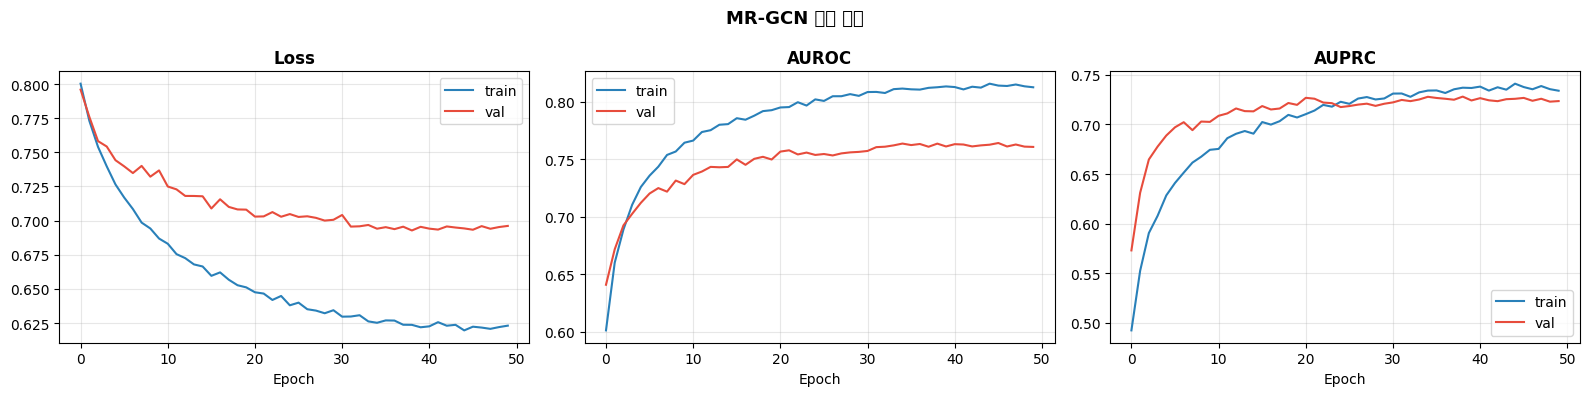

In [12]:
# ── 8. 학습 곡선 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('MR-GCN 학습 곡선', fontsize=13, fontweight='bold')

for ax, tr_k, va_k, title in zip(
    axes,
    ['tr_loss',  'tr_auroc', 'tr_auprc'],
    ['va_loss',  'va_auroc', 'va_auprc'],
    ['Loss',     'AUROC',    'AUPRC'],
):
    ax.plot(history[tr_k], label='train', color='#2980B9')
    ax.plot(history[va_k], label='val',   color='#E74C3C')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/mrgcn_train_curves.png', dpi=150, bbox_inches='tight')
plt.show()

  Test AUROC : 0.7866
  Test AUPRC : 0.7067
  Test F1    : 0.6860

              precision    recall  f1-score   support

       숨김(0)       0.80      0.67      0.73      4547
       출현(1)       0.62      0.76      0.69      3275

    accuracy                           0.71      7822
   macro avg       0.71      0.72      0.71      7822
weighted avg       0.72      0.71      0.71      7822



C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\2857173564.py:50: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\2857173564.py:50: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\2857173564.py:50: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\2857173564.py:50: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\2857173564.py:50: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jien0\AppData\Local\Temp\ipykernel_22028\2857173564.py:51: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing f

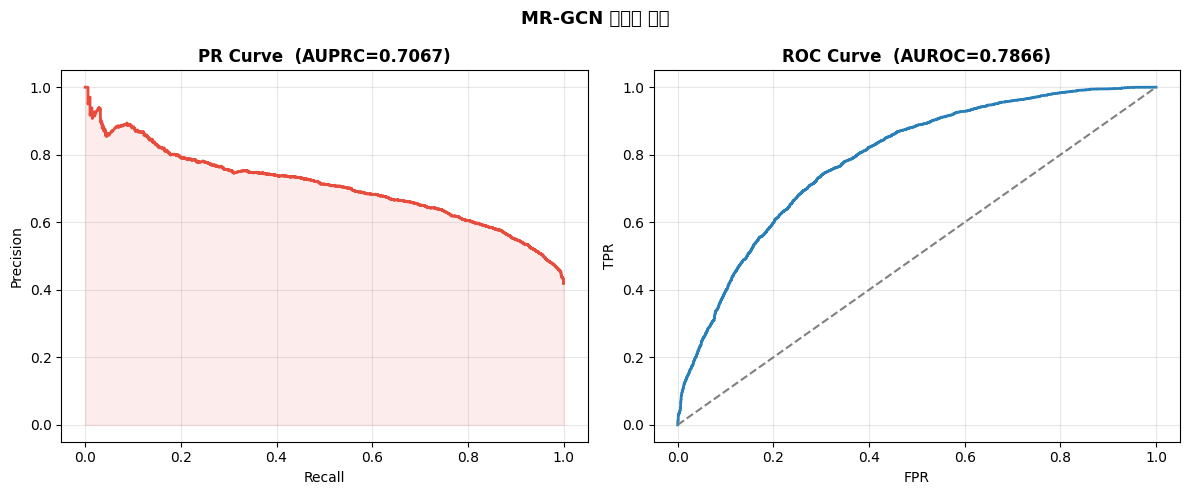

In [13]:
# ── 9. 테스트셋 최종 평가 ───────────────────────────────────────
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        logits = model(
            batch.x, batch.edge_index, batch.edge_type,
            batch.bz_idx, batch.batch,
        )
        all_logits.append(logits.cpu())
        all_labels.append(batch.y.squeeze(-1).cpu())

logits = torch.cat(all_logits).numpy()
labels = torch.cat(all_labels).numpy()
probs  = torch.sigmoid(torch.tensor(logits)).numpy()
preds  = (probs >= 0.5).astype(int)

auroc = roc_auc_score(labels, probs)
auprc = average_precision_score(labels, probs)
f1    = f1_score(labels, preds, zero_division=0)

print('=' * 50)
print(f'  Test AUROC : {auroc:.4f}')
print(f'  Test AUPRC : {auprc:.4f}')
print(f'  Test F1    : {f1:.4f}')
print('=' * 50)
print()
print(classification_report(labels, preds, target_names=['숨김(0)', '출현(1)']))

# PR / ROC 곡선
prec, rec, thr = precision_recall_curve(labels, probs)
fpr,  tpr, _   = roc_curve(labels, probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('MR-GCN 테스트 성능', fontsize=13, fontweight='bold')

axes[0].plot(rec, prec, color='#E74C3C', lw=2)
axes[0].fill_between(rec, prec, alpha=0.1, color='#E74C3C')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'PR Curve  (AUPRC={auprc:.4f})', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(fpr, tpr, color='#2980B9', lw=2)
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'ROC Curve  (AUROC={auroc:.4f})', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/mrgcn_test_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 10. Threshold 분석 (Safety: Recall 우선) ────────────────────
f1_scores = 2*prec[:-1]*rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_f1_i = np.argmax(f1_scores)
print(f'[Max F1 threshold]  thr={thr[best_f1_i]:.3f}  '
      f'F1={f1_scores[best_f1_i]:.4f}  P={prec[best_f1_i]:.3f}  R={rec[best_f1_i]:.3f}')

mask = rec[:-1] >= 0.85
if mask.any():
    bi = np.argmax(prec[:-1][mask])
    print(f'[Recall≥0.85]       thr={thr[mask][bi]:.3f}  '
          f'P={prec[:-1][mask][bi]:.3f}  R={rec[:-1][mask][bi]:.3f}')
    preds_safe = (probs >= thr[mask][bi]).astype(int)
    print(classification_report(labels, preds_safe, target_names=['숨김(0)', '출현(1)']))
else:
    print('[Recall≥0.85] 달성 불가')

In [ ]:
# ── 11. Relation별 가중치 분석 ──────────────────────────────────
# basis decomposition: W_r = Σ_b a_{rb} · V_b
# a_rb (relation별 basis 계수)를 시각화

with torch.no_grad():
    # conv1의 basis 계수 [num_relations, num_bases]
    w1 = model.conv1.att.detach().cpu().numpy()  # [num_relations, num_bases]

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    w1, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax,
    xticklabels=[f'B{i}' for i in range(w1.shape[1])],
    yticklabels=RELATION_TYPES,
)
ax.set_title('Conv1 Relation Basis Coefficients', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/mrgcn_relation_weights.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 12. 모델 저장 ────────────────────────────────────────────────
save_path = Path('../data/blindspotter_mrgcn.pt')
torch.save({
    'model_state': model.state_dict(),
    'config': {
        'node_dim': NODE_DIM, 'num_relations': NUM_RELATIONS,
        'hidden': HIDDEN, 'dropout': DROPOUT,
        'decomp': DECOMPOS, 'n_bases': N_BASES,
    },
    'relation_types': RELATION_TYPES,
    'rel2id': REL2ID,
    'metrics': {'auroc': float(auroc), 'auprc': float(auprc), 'f1': float(f1)},
    'node_feature_names': raw['node_feature_names'],
}, save_path)
print(f'저장: {save_path}')
print(f'AUROC={auroc:.4f}  AUPRC={auprc:.4f}  F1={f1:.4f}')

---
## GAT vs MR-GCN 비교

| | GATv2 | MR-GCN (이 노트북) |
|---|---|---|
| 엣지 타입 처리 | edge_attr (연속값) | 관계별 $W_r$ (이산 타입) |
| 엣지 피처 사용 | O (5-dim) | X (타입만 사용) |
| Attention | O (노드·엣지 기반) | X |
| 파라미터 | ~8만 | basis decomp로 절감 |
| 장점 | 엣지 피처 활용 | 관계 의미 명시적 분리 |

### 개선 방향
- `RGCNConv` + `edge_attr` 동시 활용 → `FastRGCNConv` 또는 커스텀 레이어
- Temporal: GRU로 프레임 시퀀스 인코딩
- `GNNExplainer`로 relation별 기여도 분석